## 1. Introdução ao dataset

O presente estudo realiza uma análise exploratória do conjunto de dados "Air Quality UCI". Este dataset é de grande relevância para a área de ciências ambientais e aprendizado de máquina, pois contém registros detalhados da qualidade do ar de uma cidade metropolitana italiana, coletados entre março de 2004 e fevereiro de 2005.

Os dados foram capturados por um dispositivo multisensor que media, em intervalos horários, a concentração de diversos poluentes atmosféricos, como monóxido de carbono (CO), benzeno (C6H6) e óxidos de nitrogênio (NOx), além de registrar condições meteorológicas como temperatura e umidade.

A análise deste conjunto de dados visa identificar padrões, distribuições e correlações entre as variáveis, fornecendo insights valiosos sobre a dinâmica da poluição do ar em um ambiente urbano. O entendimento dessas características é o primeiro passo para a construção de modelos preditivos e para a avaliação do impacto ambiental na saúde pública.

## 2. Descrição dataset

#### 2.1 Importando bibliotecas

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import warnings

#### 2.2 Configurações

In [67]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

warnings.filterwarnings('ignore')
# Add parent directory to sys.path for module imports
sys.path.append('..')

#### 2.2 Carregando dataset

In [68]:
# Carrega o dataset 
data_path = "../database/air_quality_uci.csv"
air_quality = pd.read_csv(data_path,
                          sep=";",
                          decimal=",", 
                          na_values=-200,
                          date_format="%d/%m/%Y %H.%M.%S",
                          parse_dates={"datetime": ["Date", "Time"]}, 
                          index_col="datetime")  

# Converting 'datetime' column to datetime format with error coercion
air_quality.index = pd.to_datetime(air_quality.index, format="%d/%m/%Y %H.%M.%S", errors="coerce")

# Remoção de duas colunas vazias que estão no final do dataset
air_quality = air_quality.iloc[:, :-2]

# Exibir 5 linhas aleatórias para verificar se foi carregado corretamente
print(f"Dataset shape: {air_quality.shape}")
print("Cabeçalho do DataFrame:")
air_quality.sample(5)

Dataset shape: (9471, 13)
Cabeçalho do DataFrame:


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-11-12 12:00:00,1.7,1014.0,NaN,6.7,843.0,279.0,791.0,116.0,1297.0,866.0,16.9,56.5,1.0801
2005-02-23 10:00:00,1.4,944.0,NaN,3.8,697.0,243.0,881.0,167.0,1022.0,688.0,3.1,83.0,0.6419
2005-01-03 11:00:00,1.7,NaN,NaN,NaN,NaN,285.0,NaN,117.0,NaN,NaN,NaN,NaN,NaN
2004-06-01 12:00:00,1.9,1259.0,NaN,15.9,1178.0,191.0,722.0,89.0,2060.0,1367.0,21.6,61.8,1.5775
2004-05-17 23:00:00,1.3,1003.0,NaN,7.4,872.0,79.0,988.0,80.0,1439.0,851.0,20.2,31.2,0.7304


#### 2.3 Obter número de instâncias e variáveis

In [69]:
print("Dimensões:", air_quality.shape)  # linhas e colunas

Dimensões: (9471, 13)


In [70]:
print("Valores nulos por coluna:\n")
air_quality.isna().sum()

Valores nulos por coluna:



CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

#### 2.4 Listagem de variáveis

In [71]:
# Lista variáveis, tipos de dados e contagem de valores não nulos
print("Dataset Information:")
print("=" * 80)
air_quality.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9471 entries, 2004-03-10 18:00:00 to NaT
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       914 non-null    float64
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        7718 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        7715 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              8991 non-null   float64
 11  RH             8991 non-null   float64
 12  AH             8991 non-null   float64
dtypes: float64(13)
memory usage: 1.0 MB


#### 2.5 Contagem de valores nulos por variáveis

In [72]:
print("\nMissing Values:")
air_quality.isnull().sum()


Missing Values:


CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

In [73]:
print(f"\nTotal missing values: {air_quality.isnull().sum().sum()}")


Total missing values: 18183


### 2.6 Apagar linhas duplicadas

In [74]:
# drop duplicate rows
air_quality.drop_duplicates(inplace=True)

# 3. Estátisticas univariadas incondicionais

#### 3.1 Calculo da media
<span style="font-size: 15px;">A média, ou valor médio, é a medida de tendência central mais comum. No contexto do nosso dataset, ela nos dará um valor "típico" para cada sensor e medição ao longo de todo o período de coleta. </span>

In [75]:
# Cálculo da média para cada variável numérica
print("Média para cada variável:")
air_quality.mean(numeric_only=True)

Média para cada variável:


CO(GT)              2.152926
PT08.S1(CO)      1099.833166
NMHC(GT)          218.811816
C6H6(GT)           10.083105
PT08.S2(NMHC)     939.153376
NOx(GT)           246.896735
PT08.S3(NOx)      835.493605
NO2(GT)           113.091251
PT08.S4(NO2)     1456.264598
PT08.S5(O3)      1022.906128
T                  18.317829
RH                 49.234201
AH                  1.025530
dtype: float64

#### 3.2 Calculo do desvio padrao
<span style="font-size: 15px;">O desvio padrão nos diz o quão espalhados ou variáveis os dados são em torno dessa média. Um desvio padrão baixo significa que a maioria dos valores está muito próxima da média. Os dados são consistentes e previsíveis. Um desvio padrão alto significa que os valores estão muito espalhados. Há uma grande variação nas medições, com muitos valores longe da média. 
Para o nosso dataset, o desvio padrão vai nos ajudar a entender a volatilidade de cada poluente e condição climática.</span>

In [76]:
#Cálculo do desvio padrão para cada variável numérica
print("\nDesvio padrão para cada variável:")
air_quality.std(numeric_only=True)


Desvio padrão para cada variável:


CO(GT)             1.453265
PT08.S1(CO)      217.080037
NMHC(GT)         204.459921
C6H6(GT)           7.449820
PT08.S2(NMHC)    266.831429
NOx(GT)          212.979168
PT08.S3(NOx)     256.817320
NO2(GT)           48.370108
PT08.S4(NO2)     346.206794
PT08.S5(O3)      398.484288
T                  8.832116
RH                17.316892
AH                 0.403813
dtype: float64

#### 3.3 Describe

In [77]:
air_quality.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7673.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152926,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453265,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


#### 3.4 Calculo de skewness (Assimetria)
Enquanto a média e o desvio padrão nos dão informações sobre o centro e a dispersão, a skewness nos diz sobre a forma da distribuição.
- Skewness ≈ 0: A distribuição é quase simétrica. Os dados se espalham de maneira uniforme em ambos os lados da média. A curva parece um sino (distribuição normal).
- Skewness > 0: A distribuição tem uma "cauda" mais longa à direita. Isso significa que, embora a maioria dos valores esteja concentrada à esquerda, existem alguns valores extremamente altos que "puxam" a média para a direita.
- Skewness < 0: A distribuição tem uma "cauda" mais longa à esquerda. A maioria dos valores está concentrada à direita, mas alguns valores extremamente baixos "puxam" a média para a esquerda.
No nosso caso, a Skewness vai nos dizer, por exemplo, se os picos de poluição são mais comuns do que períodos de ar excepcionalmente limpo.

In [78]:
# Calcula a skewness para todas as colunas numéricas
print("Assimetria (Skewness) para cada variável:")
air_quality.skew(numeric_only=True)

Assimetria (Skewness) para cada variável:


CO(GT)           1.369637
PT08.S1(CO)      0.755907
NMHC(GT)         1.557017
C6H6(GT)         1.361532
PT08.S2(NMHC)    0.561566
NOx(GT)          1.715781
PT08.S3(NOx)     1.101729
NO2(GT)          0.621714
PT08.S4(NO2)     0.205389
PT08.S5(O3)      0.627864
T                0.309357
RH              -0.037928
AH               0.251388
dtype: float64

### 3.4 Plotagem dos gráficos

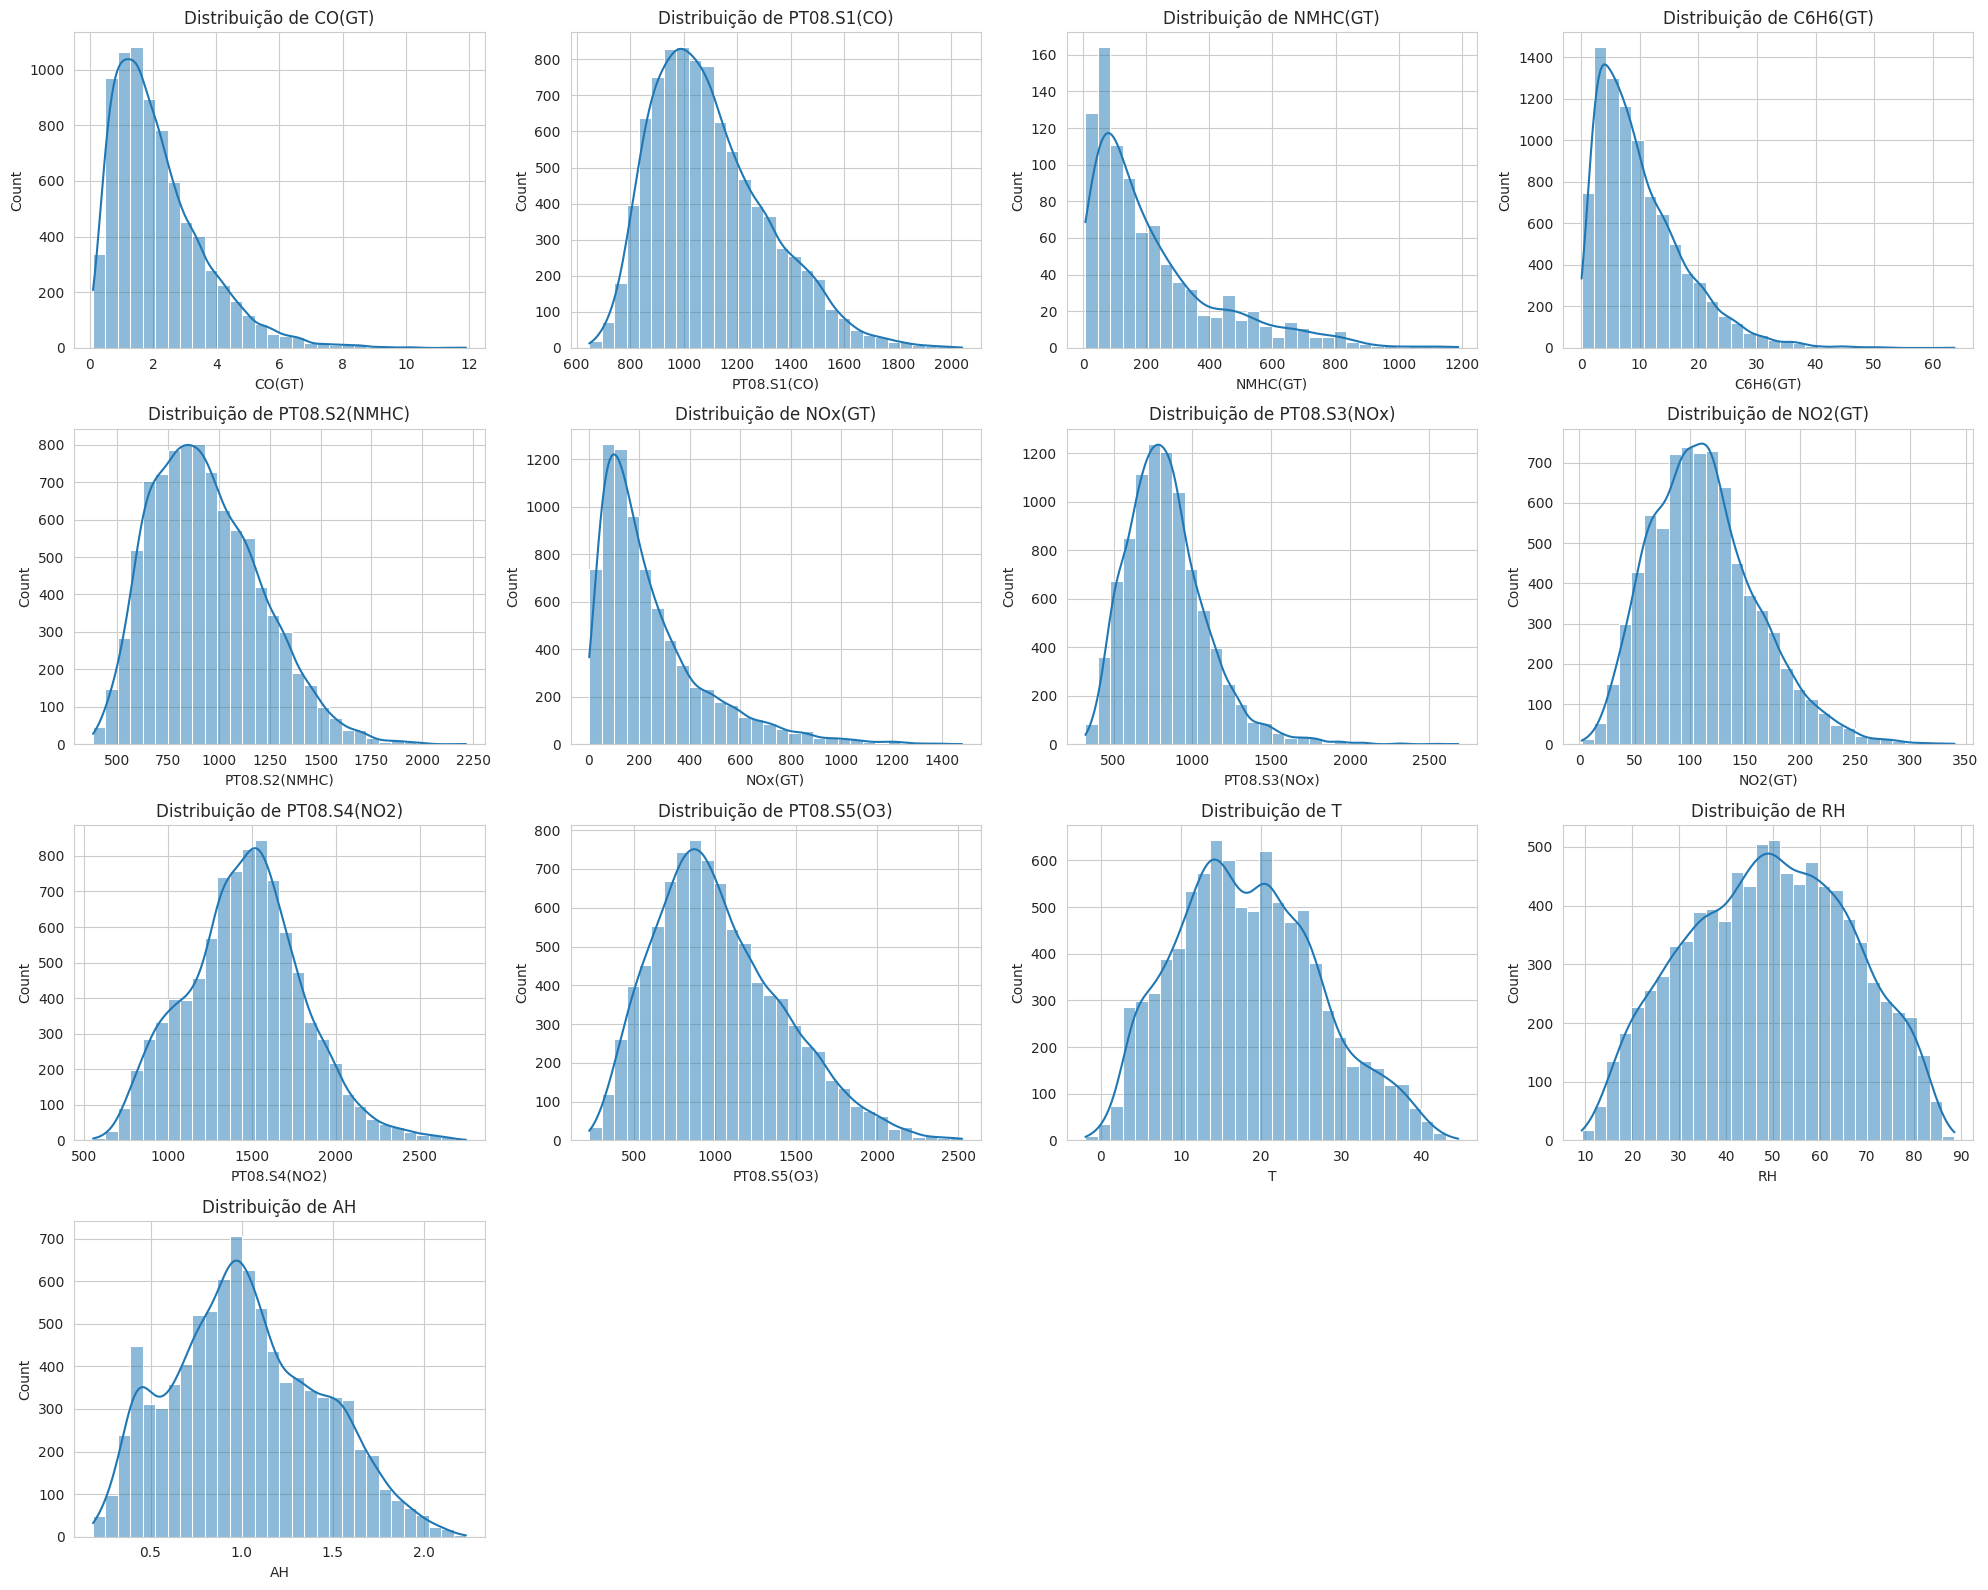

In [79]:
# Somente colunas numéricas
numeric_cols = air_quality.copy().select_dtypes(include=np.number).columns

# Define o layout da grade e o tamanho total da figura
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))

# Loop para criar histogramas para cada coluna numérica
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.histplot(data=air_quality, x=col, kde=True, bins=30, ax=ax)
    ax.set_title(f'Distribuição de {col}', fontsize=12)


# Esconde as colunas vazias
for i in range(len(numeric_cols), 16):
    axes.flatten()[i].axis('off')

# Espaçamento
plt.tight_layout()

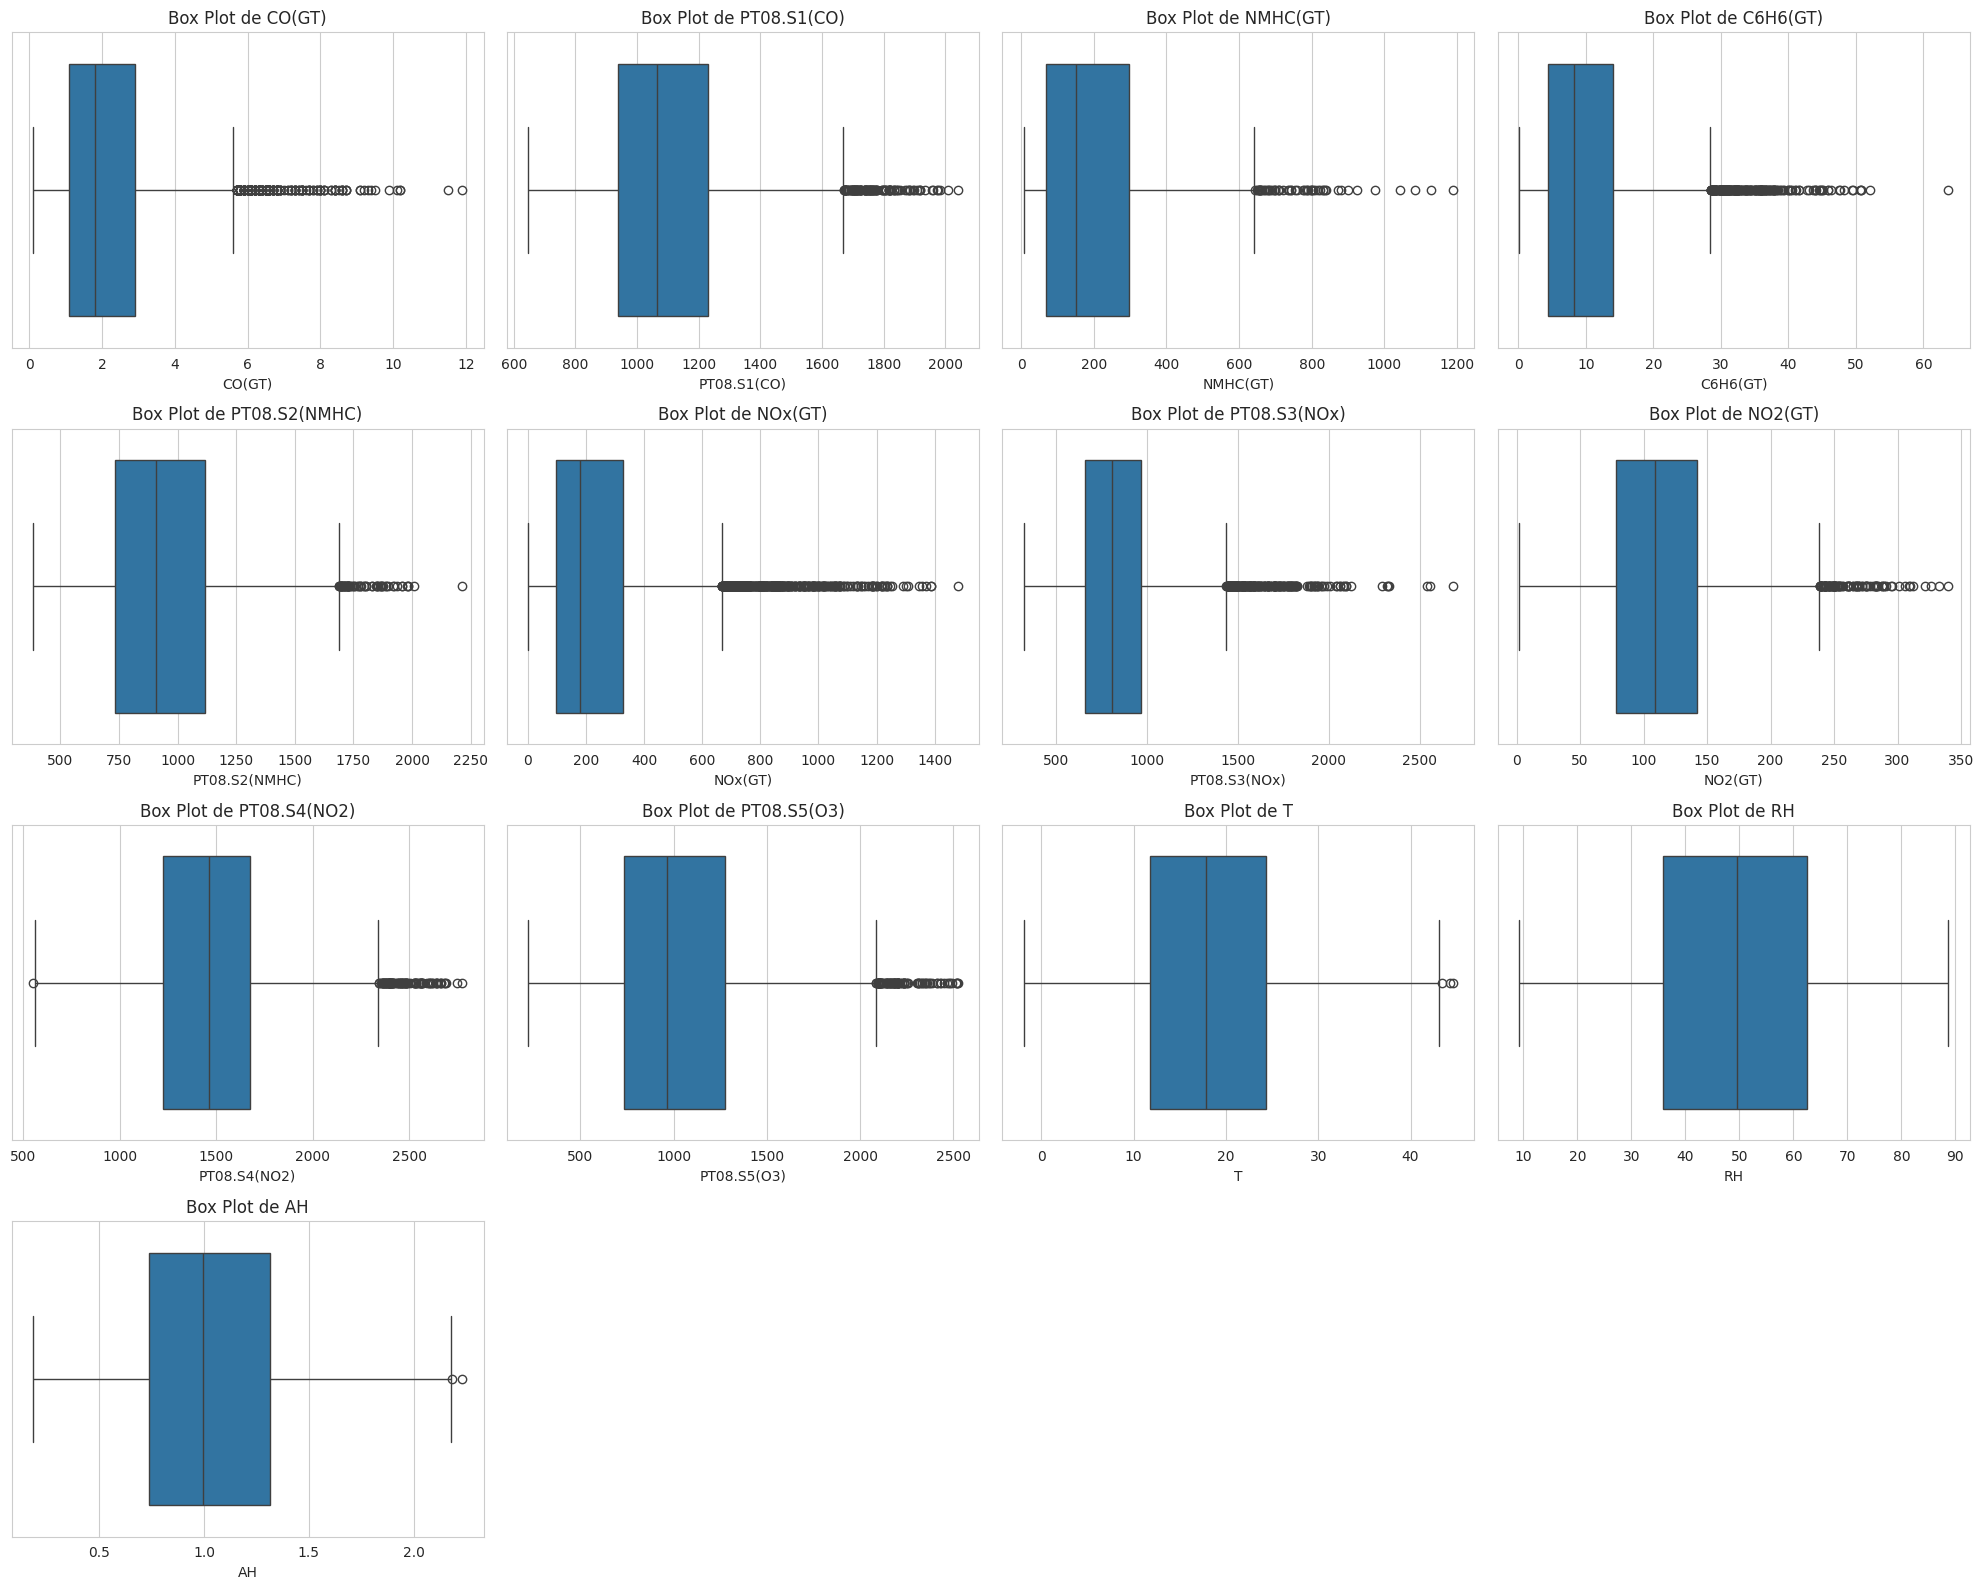

In [80]:
# Somente as colunas numéricas
numeric_cols = air_quality.select_dtypes(include=np.number).columns

# Define o layout da grade e o tamanho total da figura
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))

# Loop para criar box plots para cada coluna numérica
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(x=air_quality[col], ax=ax)
    ax.set_title(f'Box Plot de {col}', fontsize=12)

# Esconde as colunas vazias
for i in range(len(numeric_cols), 16):
    axes.flatten()[i].axis('off')

# Espaçamento
plt.tight_layout()

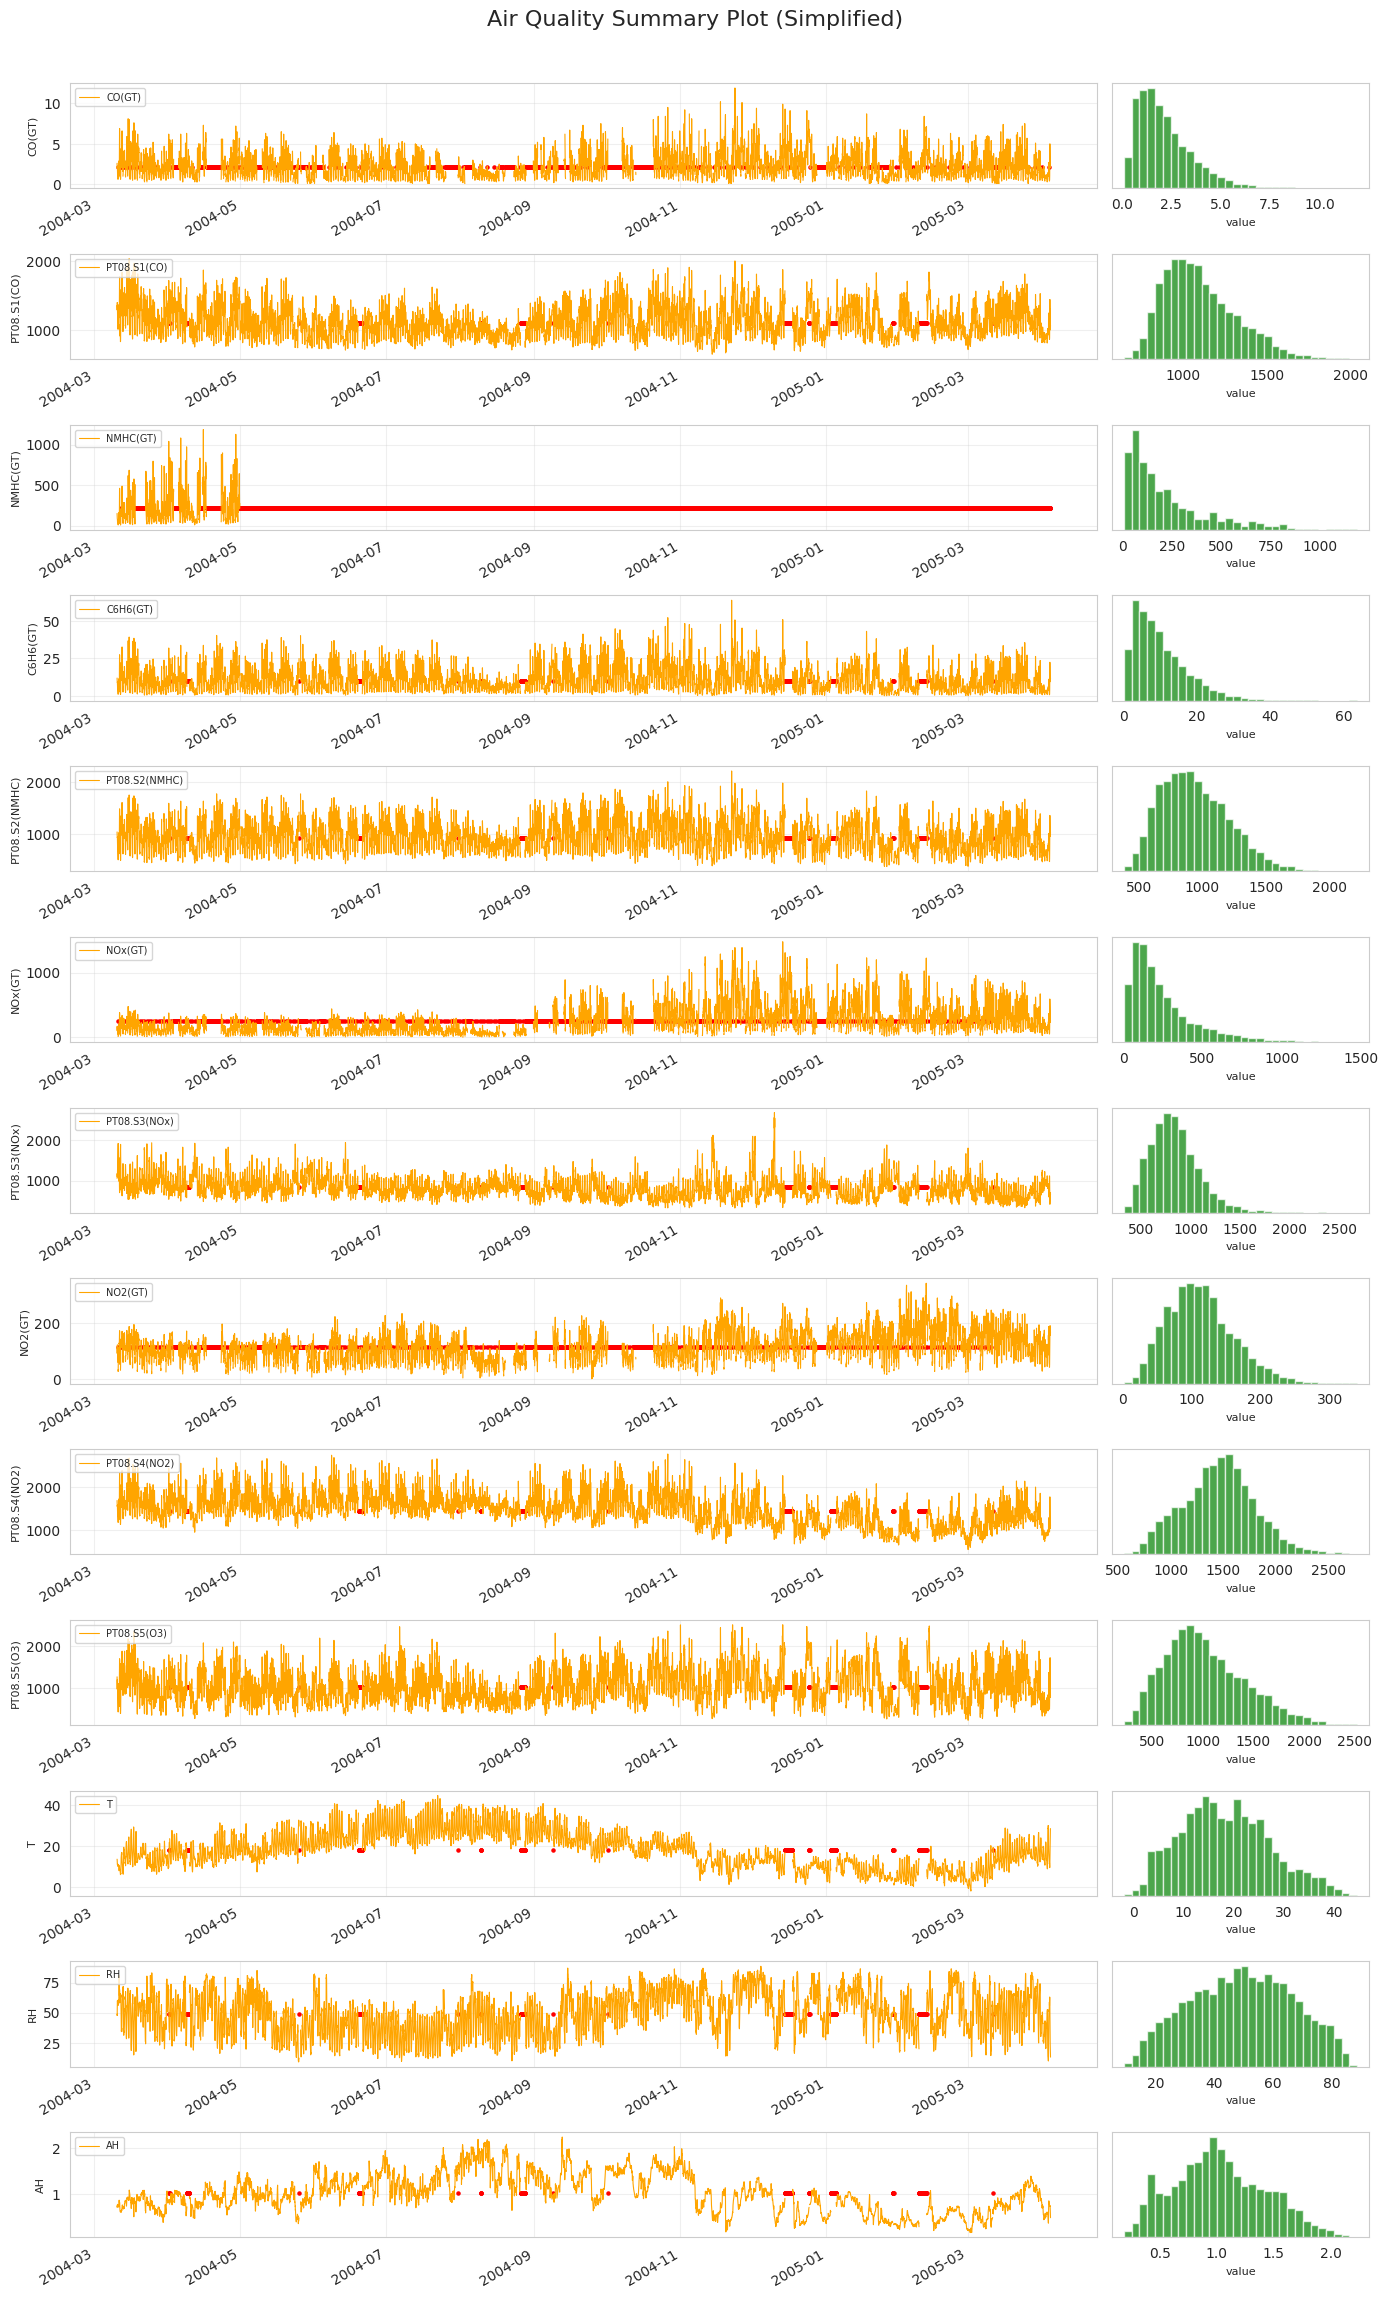

In [81]:
# Selecionar apenas colunas numéricas
cols = air_quality.select_dtypes("number").columns

# Criar figura
fig, axes = plt.subplots(nrows=len(cols), ncols=2, figsize=(14, len(cols) * 1.8),
                         gridspec_kw={"width_ratios": [4, 1]})
fig.suptitle("Air Quality Summary Plot (Simplified)", fontsize=16)

for i, col in enumerate(cols):
    # --- Série temporal ---
    ax_ts = axes[i, 0]
    air_quality[col].plot(ax=ax_ts, lw=0.8, color="orange", label=col)
    ax_ts.set_ylabel(col, fontsize=8)
    ax_ts.set_xlabel("")
    ax_ts.legend(loc="upper left", fontsize=7)
    ax_ts.grid(True, alpha=0.3)
    
    # Destacar valores faltantes
    na_mask = air_quality[col].isna()
    ax_ts.scatter(air_quality.index[na_mask], [air_quality[col].mean()]*na_mask.sum(),
                  color="red", s=5, label="missing")
    
    # --- Histograma ---
    ax_hist = axes[i, 1]
    air_quality[col].hist(ax=ax_hist, bins=30, color="green", alpha=0.7)
    ax_hist.set_ylabel("")
    ax_hist.set_xlabel("value", fontsize=8)
    ax_hist.grid(False)
    ax_hist.tick_params(axis="y", labelleft=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [82]:
air_quality_targets = air_quality[
    [
        "CO(GT)",      # Monóxido de carbono (mg/m³)
        "NMHC(GT)",    # Hidrocarbonetos não metânicos (µg/m³)
        "C6H6(GT)",    # Benzeno (µg/m³)
        "NOx(GT)",     # Óxidos de nitrogênio totais (ppb)
        "NO2(GT)"      # Dióxido de nitrogênio (µg/m³)
    ]
]

air_quality_predictors = air_quality[
    [
        "PT08.S1(CO)",     # Sensor 1 — SnO₂ (CO)
        "PT08.S2(NMHC)",   # Sensor 2 — TiO₂ (NMHC)
        "PT08.S3(NOx)",    # Sensor 3 — WO₃ (NOx)
        "PT08.S4(NO2)",    # Sensor 4 — WO₃ (NO₂)
        "PT08.S5(O3)",     # Sensor 5 — In₂O₃ (O₃)
        "T",               # Temperatura (°C)
        "RH",              # Umidade relativa (%)
        "AH"               # Umidade absoluta (g/m³)
    ]
]

In [83]:
air_quality

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.0,NaN,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
2005-04-04 11:00:00,2.4,1163.0,NaN,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
2005-04-04 12:00:00,2.4,1142.0,NaN,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406


# 4. Estátisticas univariadas incondicionais condicionada por classes